## Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## Load Dataset

In [2]:
df = pd.read_csv("mortgage_covenant_data.csv")
df.to_csv("hennepin_analysis.csv", index=False)

print("File converted successfully")

File converted successfully


## Perform EDA

In [3]:
df.shape

(100931, 14)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100931 entries, 0 to 100930
Data columns (total 14 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   activity_year                      100931 non-null  int64  
 1   census_tract                       99915 non-null   float64
 2   derived_race                       100931 non-null  object 
 3   action_taken                       100931 non-null  int64  
 4   loan_amount                        100931 non-null  float64
 5   property_value                     83491 non-null   float64
 6   income                             88200 non-null   float64
 7   interest_rate                      78125 non-null   float64
 8   tract_minority_population_percent  100931 non-null  float64
 9   tract_to_msa_income_percentage     100931 non-null  float64
 10  denial_reason-1                    100931 non-null  int64  
 11  covenant_count                     1009

In [5]:
print("\nColumn names:")
print(df.columns)


Column names:
Index(['activity_year', 'census_tract', 'derived_race', 'action_taken',
       'loan_amount', 'property_value', 'income', 'interest_rate',
       'tract_minority_population_percent', 'tract_to_msa_income_percentage',
       'denial_reason-1', 'covenant_count', 'was_approved',
       'covenant_density'],
      dtype='object')


In [6]:
df.head(10)

,activity_year,census_tract,derived_race,action_taken,loan_amount,property_value,income,interest_rate,tract_minority_population_percent,tract_to_msa_income_percentage,denial_reason-1,covenant_count,was_approved,covenant_density
0,2023,2.703706e+10,Race Not Available,6,185000.0,195000.0,NaN,6.125,40.37,73.48,10,0.0,False,NaN
1,2023,2.714103e+10,Race Not Available,6,375000.0,385000.0,NaN,6.625,10.64,121.26,10,0.0,False,NaN
2,2023,2.702395e+10,Race Not Available,6,105000.0,105000.0,NaN,6.125,8.92,90.13,10,0.0,False,NaN
3,2023,2.717110e+10,Race Not Available,6,285000.0,285000.0,NaN,6.750,13.27,104.37,10,0.0,False,NaN
4,2023,2.715948e+10,Race Not Available,6,175000.0,175000.0,NaN,6.875,5.87,82.22,10,0.0,False,NaN
5,2023,2.716307e+10,Race Not Available,6,185000.0,245000.0,NaN,6.250,20.25,152.30,10,0.0,False,NaN
6,2023,2.712303e+10,Race Not Available,6,235000.0,245000.0,NaN,6.750,84.32,39.16,10,0.0,False,NaN
7,2023,2.708595e+10,Race Not Available,6,225000.0,225000.0,NaN,6.250,9.68,115.40,10,0.0,False,NaN
8,2023,2.700305e+10,Race Not Available,6,315000.0,325000.0,NaN,7.125,18.86,86.27,10,0.0,False,NaN
9,2023,2.713700e+10,Race Not Available,6,195000.0,235000.0,NaN,6.625,18.53,69.66,10,0.0,False,NaN


In [7]:
print("\nMissing values:")
df.isnull().sum()


Missing values:


activity_year                            0
census_tract                          1016
derived_race                             0
action_taken                             0
loan_amount                              0
property_value                       17440
income                               12731
interest_rate                        22806
tract_minority_population_percent        0
tract_to_msa_income_percentage           0
denial_reason-1                          0
covenant_count                           0
was_approved                             0
covenant_density                     89762
dtype: int64

In [8]:
print("\nSummary statistics:")
df.describe()


Summary statistics:


,activity_year,census_tract,action_taken,loan_amount,property_value,income,interest_rate,tract_minority_population_percent,tract_to_msa_income_percentage,denial_reason-1,covenant_count
count,100931.0,9.991500e+04,100931.000000,1.009310e+05,8.349100e+04,8.820000e+04,78125.000000,100931.000000,100931.000000,100931.000000,100931.000000
mean,2023.0,2.708025e+10,2.309528,3.110060e+05,3.987726e+05,1.489660e+02,6.575084,22.874029,101.813583,48.624763,17.408101
std,0.0,5.254319e+07,1.950185,7.617088e+05,1.197102e+06,5.568826e+03,1.273054,17.292952,32.381060,203.617075,84.973673
min,2023.0,2.700177e+10,1.000000,5.000000e+03,5.000000e+03,-3.415700e+04,0.000000,0.000000,0.000000,1.000000,0.000000
25%,2023.0,2.703706e+10,1.000000,1.750000e+05,2.350000e+05,6.700000e+01,6.125000,10.140000,82.070000,10.000000,0.000000
50%,2023.0,2.705311e+10,1.000000,2.650000e+05,3.250000e+05,9.600000e+01,6.625000,18.640000,99.060000,10.000000,0.000000
75%,2023.0,2.712304e+10,4.000000,3.650000e+05,4.350000e+05,1.460000e+02,7.125000,29.710000,119.950000,10.000000,0.000000
max,2023.0,2.717397e+10,8.000000,5.700500e+07,1.113250e+08,1.651000e+06,15.500000,95.630000,240.430000,1111.000000,965.000000


In [9]:
print("\nDuplicate rows:", df.duplicated().sum())


Duplicate rows: 791


In [10]:
df['activity_year'].value_counts()

activity_year
2023    100931
Name: count, dtype: int64

In [11]:
df['census_tract'].value_counts()

census_tract
2.705303e+10    606
2.716307e+10    580
2.705303e+10    432
2.705303e+10    420
2.717110e+10    384
               ... 
2.712304e+10      4
2.712303e+10      3
2.713700e+10      2
2.714501e+10      1
2.710900e+10      1
Name: count, Length: 1494, dtype: int64

In [12]:
df['derived_race'].value_counts()

derived_race
White                                        63627
Race Not Available                           22811
Asian                                         5905
Black or African American                     5199
Joint                                         2427
American Indian or Alaska Native               709
2 or more minority races                       135
Native Hawaiian or Other Pacific Islander      113
Free Form Text Only                              5
Name: count, dtype: int64

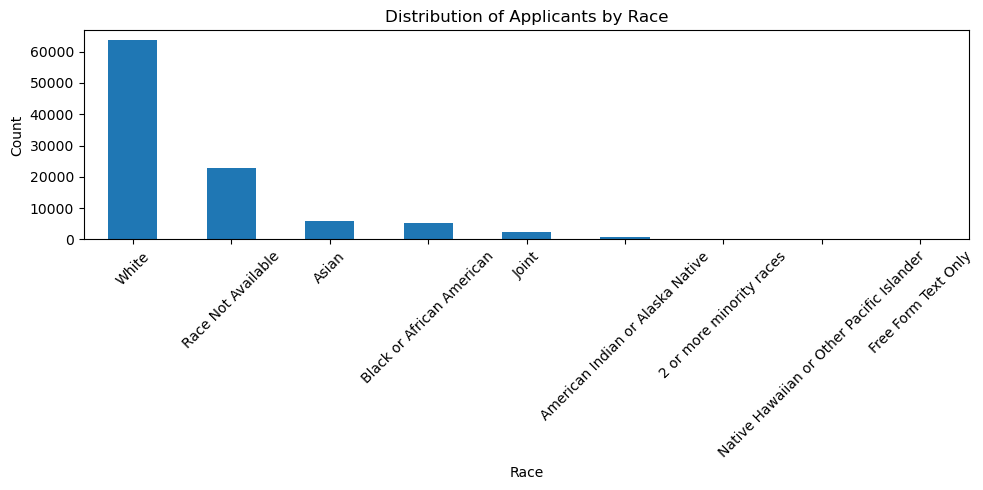

In [13]:
plt.figure(figsize=(10,5))
df["derived_race"].value_counts().plot(kind="bar")
plt.title("Distribution of Applicants by Race")
plt.xlabel("Race")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
df['action_taken'].value_counts()

action_taken
1    65329
6    15687
4    10508
3     5796
2     1756
5     1320
8      375
7      160
Name: count, dtype: int64

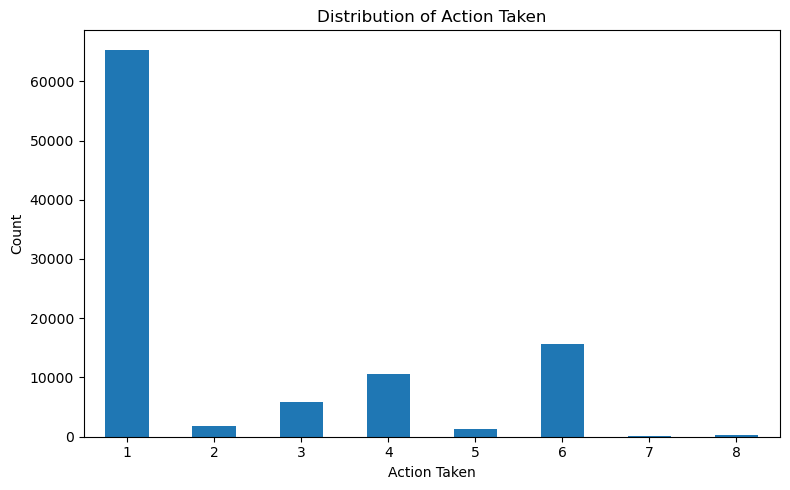

In [15]:
action_counts = df["action_taken"].value_counts().sort_index()

plt.figure(figsize=(8,5))
action_counts.plot(kind="bar")
plt.title("Distribution of Action Taken")
plt.xlabel("Action Taken")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [16]:
df['loan_amount'].value_counts()

loan_amount
15000.0       3841
245000.0      3119
255000.0      3107
265000.0      2993
305000.0      2991
              ... 
1865000.0        1
4165000.0        1
14005000.0       1
1945000.0        1
2015000.0        1
Name: count, Length: 359, dtype: int64

In [17]:
df['property_value'].value_counts()

property_value
255000.0      2527
275000.0      2499
285000.0      2498
265000.0      2440
325000.0      2428
              ... 
74305000.0       1
2115000.0        1
3425000.0        1
2335000.0        1
9005000.0        1
Name: count, Length: 379, dtype: int64

In [18]:
df['income'].value_counts()

income
80.0       1017
60.0       1016
70.0        958
75.0        951
90.0        915
           ... 
1760.0        1
10415.0       1
3215.0        1
2185.0        1
1087.0        1
Name: count, Length: 1141, dtype: int64

In [19]:
df['interest_rate'].value_counts()

interest_rate
6.625    5131
6.500    4921
6.750    4699
6.875    4568
7.125    3904
         ... 
6.267       1
5.991       1
6.774       1
6.216       1
7.820       1
Name: count, Length: 1319, dtype: int64

In [20]:
df['tract_minority_population_percent'].value_counts()

tract_minority_population_percent
0.00     1016
20.69     649
27.78     580
10.98     573
14.61     441
         ... 
83.09       6
27.64       5
43.94       4
95.63       3
23.88       1
Name: count, Length: 1245, dtype: int64

In [21]:
df['tract_to_msa_income_percentage'].value_counts()

tract_to_msa_income_percentage
0.00      1162
121.35     606
156.68     580
95.42      561
104.59     441
          ... 
113.97       6
124.72       6
33.47        3
38.37        2
57.35        1
Name: count, Length: 1371, dtype: int64

In [22]:
df['denial_reason-1'].value_counts()

denial_reason-1
10      91544
1111     3576
1        2231
3        1204
4         773
9         471
7         401
5         279
6         271
2         180
8           1
Name: count, dtype: int64

In [23]:
df['covenant_count'].value_counts()

covenant_count
0.0      89762
1.0        684
3.0        532
2.0        488
212.0      294
         ...  
176.0       29
15.0        28
57.0        27
126.0       27
485.0       25
Name: count, Length: 112, dtype: int64

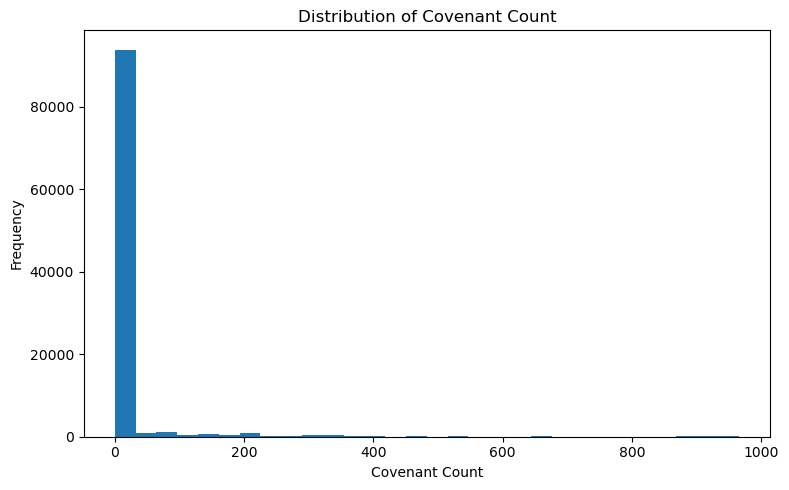

In [24]:
plt.figure(figsize=(8,5))
df["covenant_count"].dropna().plot(kind="hist", bins=30)
plt.title("Distribution of Covenant Count")
plt.xlabel("Covenant Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [25]:
df['was_approved'].value_counts()



was_approved
True     67085
False    33846
Name: count, dtype: int64

In [26]:
df['covenant_density'].value_counts()

covenant_density
Low (1-50)          4537
Very High (>200)    3140
Medium (51-100)     1772
High (101-200)      1720
Name: count, dtype: int64

In [27]:
# Median values by race
race_summary = df.groupby("derived_race")[[
    "income",
    "property_value",
    "loan_amount",
    "tract_minority_population_percent",
    "tract_to_msa_income_percentage",
    "covenant_count"
]].median()

print(race_summary)

                                           income  property_value  \
derived_race                                                        
2 or more minority races                     83.0        295000.0   
American Indian or Alaska Native             76.0        265000.0   
Asian                                       102.0        355000.0   
Black or African American                    87.0        335000.0   
Free Form Text Only                         109.0        385000.0   
Joint                                       122.0        355000.0   
Native Hawaiian or Other Pacific Islander    64.5        255000.0   
Race Not Available                           95.0        335000.0   
White                                        96.0        315000.0   

                                           loan_amount  \
derived_race                                             
2 or more minority races                      255000.0   
American Indian or Alaska Native              215000.0   
Asian   

In [28]:
# Approval rate by race
race_approval = df.groupby("derived_race")["was_approved"].agg(["count", "mean"])
race_approval["approval_rate_percent"] = (race_approval["mean"] * 100).round(2)

print(race_approval[["count", "approval_rate_percent"]].sort_values(by="approval_rate_percent", ascending=False))

                                           count  approval_rate_percent
derived_race                                                           
Free Form Text Only                            5                  80.00
White                                      63627                  75.61
Joint                                       2427                  74.41
Asian                                       5905                  70.77
2 or more minority races                     135                  65.93
American Indian or Alaska Native             709                  62.20
Black or African American                   5199                  60.42
Native Hawaiian or Other Pacific Islander    113                  56.64
Race Not Available                         22811                  40.57


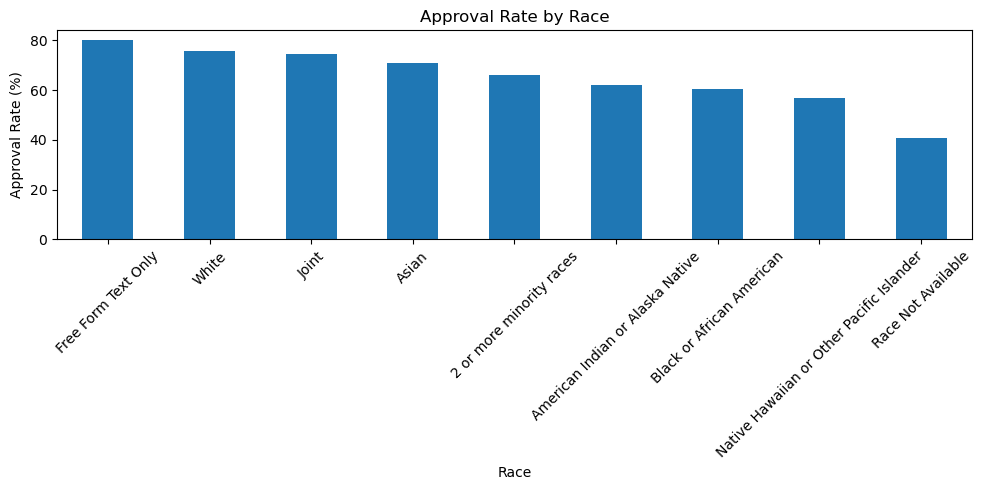

In [29]:
approval_plot = race_approval["approval_rate_percent"].sort_values(ascending=False)

plt.figure(figsize=(10,5))
approval_plot.plot(kind="bar")
plt.title("Approval Rate by Race")
plt.xlabel("Race")
plt.ylabel("Approval Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Data Bias

In [30]:
# Create covenant variables
df["covenant_binary"] = np.where(
    df["covenant_count"].fillna(0) > 0,
    "Covenanted",
    "Non-Covenanted"
)

bins = [-1, 0, 50, 100, 200, np.inf]
labels = ["0", "1-50", "51-100", "101-200", ">200"]

df["covenant_group"] = pd.cut(
    df["covenant_count"].fillna(0),
    bins=bins,
    labels=labels
)

In [31]:
app = df[df["action_taken"].isin([1, 2, 3, 7, 8])].copy()
app["approved_clean"] = app["action_taken"].isin([1, 2, 8])

app["covenant_group"] = pd.cut(
    app["covenant_count"].fillna(0),
    bins=bins,
    labels=labels
)


Median property value by covenant group:
covenant_group
0          315000.0
1-50       325000.0
51-100     365000.0
101-200    375000.0
>200       385000.0
Name: property_value, dtype: float64


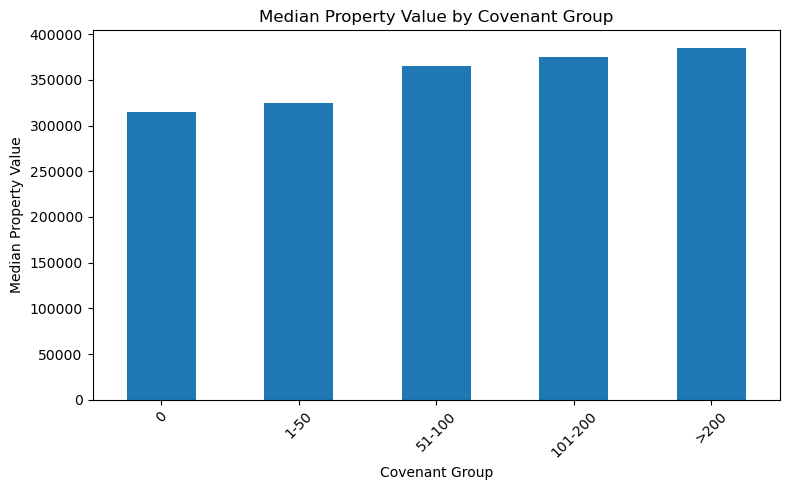

In [32]:
#  Property value by covenant group
property_by_covenant = df.groupby("covenant_group", observed=False)["property_value"].median()
print("\nMedian property value by covenant group:")
print(property_by_covenant)

plt.figure(figsize=(8, 5))
property_by_covenant.plot(kind="bar")
plt.title("Median Property Value by Covenant Group")
plt.xlabel("Covenant Group")
plt.ylabel("Median Property Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Property / neighborhood summary by covenant status:
                 median_property_value  mean_property_value  median_income  \
covenant_binary                                                              
Covenanted                    355000.0        487349.429698          111.0   
Non-Covenanted                315000.0        387560.383214           94.0   

                 avg_minority_pct  avg_tract_msa_income  
covenant_binary                                          
Covenanted              30.374508            110.928425  
Non-Covenanted          21.940751            100.679432  


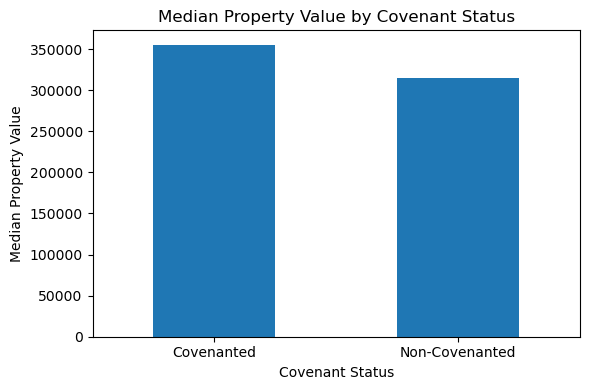

In [33]:
#  Property / neighborhood summary by covenant status
property_binary = df.groupby("covenant_binary").agg(
    median_property_value=("property_value", "median"),
    mean_property_value=("property_value", "mean"),
    median_income=("income", "median"),
    avg_minority_pct=("tract_minority_population_percent", "mean"),
    avg_tract_msa_income=("tract_to_msa_income_percentage", "mean")
)

print("\nProperty / neighborhood summary by covenant status:")
print(property_binary)

# graph for median property value by covenant status
plt.figure(figsize=(6, 4))
property_binary["median_property_value"].plot(kind="bar")
plt.title("Median Property Value by Covenant Status")
plt.xlabel("Covenant Status")
plt.ylabel("Median Property Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

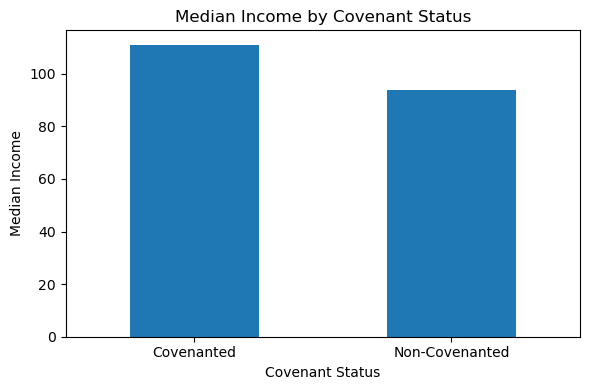

In [34]:
# graph for median income by covenant status
plt.figure(figsize=(6, 4))
property_binary["median_income"].plot(kind="bar")
plt.title("Median Income by Covenant Status")
plt.xlabel("Covenant Status")
plt.ylabel("Median Income")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Approval patterns by covenant status:
                 applications  approval_rate  denial_rate  median_income  \
covenant_binary                                                            
Covenanted               7929       0.948039     0.051961          113.0   
Non-Covenanted          65487       0.915342     0.084658           96.0   

                 median_property_value  
covenant_binary                         
Covenanted                    365000.0  
Non-Covenanted                325000.0  


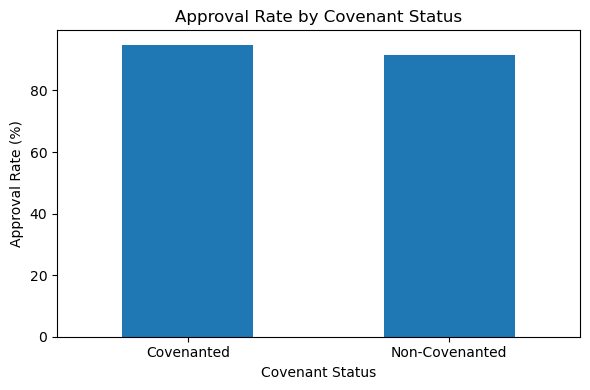

In [35]:
#Approval patterns by covenant status
approval_by_area = app.groupby("covenant_binary").agg(
    applications=("approved_clean", "size"),
    approval_rate=("approved_clean", "mean"),
    denial_rate=("approved_clean", lambda x: 1 - x.mean()),
    median_income=("income", "median"),
    median_property_value=("property_value", "median")
)

print("\nApproval patterns by covenant status:")
print(approval_by_area)

plt.figure(figsize=(6, 4))
(approval_by_area["approval_rate"] * 100).plot(kind="bar")
plt.title("Approval Rate by Covenant Status")
plt.xlabel("Covenant Status")
plt.ylabel("Approval Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Approval patterns by race:
                                           applications  approval_rate  \
derived_race                                                             
Joint                                              1939       0.933471   
White                                             51975       0.930909   
Asian                                              4557       0.918806   
Race Not Available                                10460       0.889866   
2 or more minority races                            103       0.873786   
Black or African American                          3751       0.844042   
American Indian or Alaska Native                    539       0.827458   
Free Form Text Only                                   5       0.800000   
Native Hawaiian or Other Pacific Islander            87       0.747126   

                                           denial_rate  median_income  \
derived_race                                                            
Joint      

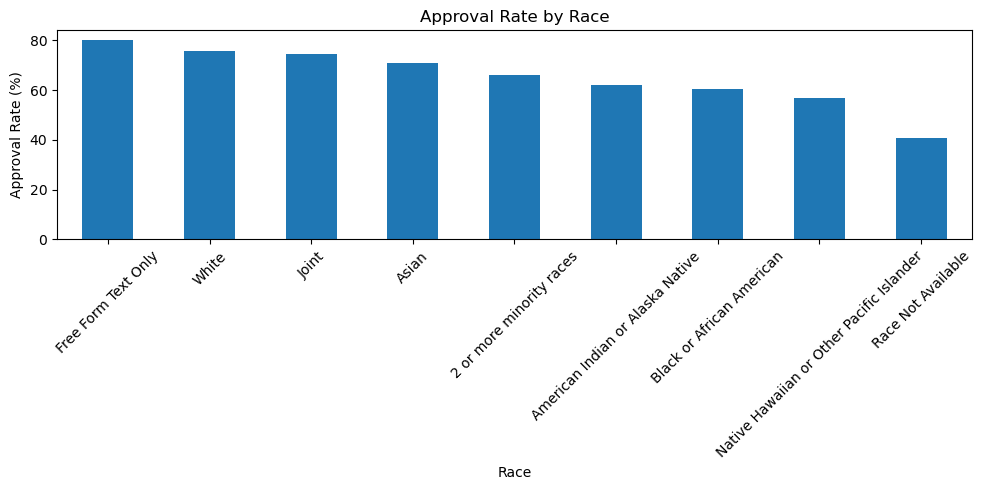

In [36]:
# Approval patterns by race
approval_by_race = app.groupby("derived_race").agg(
    applications=("approved_clean", "size"),
    approval_rate=("approved_clean", "mean"),
    denial_rate=("approved_clean", lambda x: 1 - x.mean()),
    median_income=("income", "median"),
    median_property_value=("property_value", "median"),
    avg_minority_pct=("tract_minority_population_percent", "mean"),
    avg_tract_msa_income=("tract_to_msa_income_percentage", "mean")
).sort_values("approval_rate", ascending=False)

print("\nApproval patterns by race:")
print(approval_by_race)

plt.figure(figsize=(10,5))
approval_plot.plot(kind="bar")
plt.title("Approval Rate by Race")
plt.xlabel("Race")
plt.ylabel("Approval Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


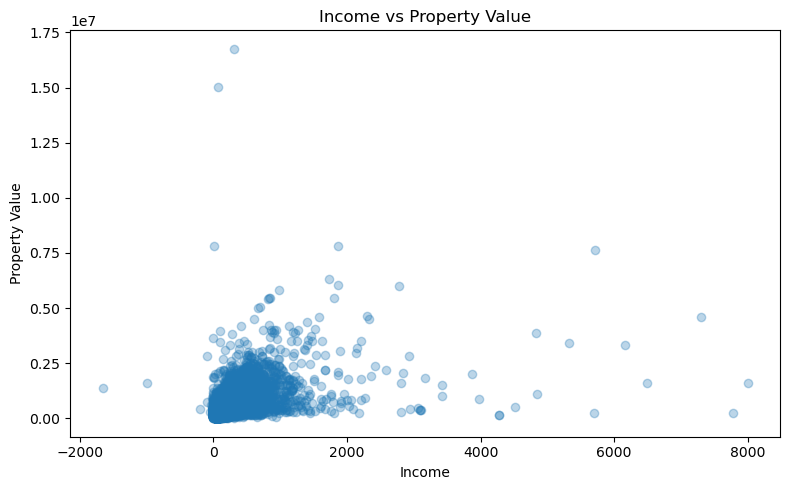

In [37]:
plt.figure(figsize=(8,5))
plt.scatter(df["income"], df["property_value"], alpha=0.3)
plt.title("Income vs Property Value")
plt.xlabel("Income")
plt.ylabel("Property Value")
plt.tight_layout()
plt.show()

In [39]:
neighborhood_summary = df.groupby("covenant_group").agg(
    avg_income=("income", "mean"),
    avg_property_value=("property_value", "mean"),
    avg_minority_pct=("tract_minority_population_percent", "mean"),
    avg_tract_income=("tract_to_msa_income_percentage", "mean")
)

print("\nNeighborhood Differences by Covenant Group:")
print(neighborhood_summary)


Neighborhood Differences by Covenant Group:
                avg_income  avg_property_value  avg_minority_pct  \
covenant_group                                                     
0               147.222444       387560.383214         21.940751   
1-50            139.971892       418831.701508         37.501120   
51-100          168.160550       567187.500000         26.929069   
101-200         181.273954       547739.916551         24.150360   
>200            184.480253       506902.255639         25.431010   

                avg_tract_income  
covenant_group                    
0                     100.679432  
1-50                   99.387064  
51-100                112.761580  
101-200               116.914163  
>200                  123.291271  


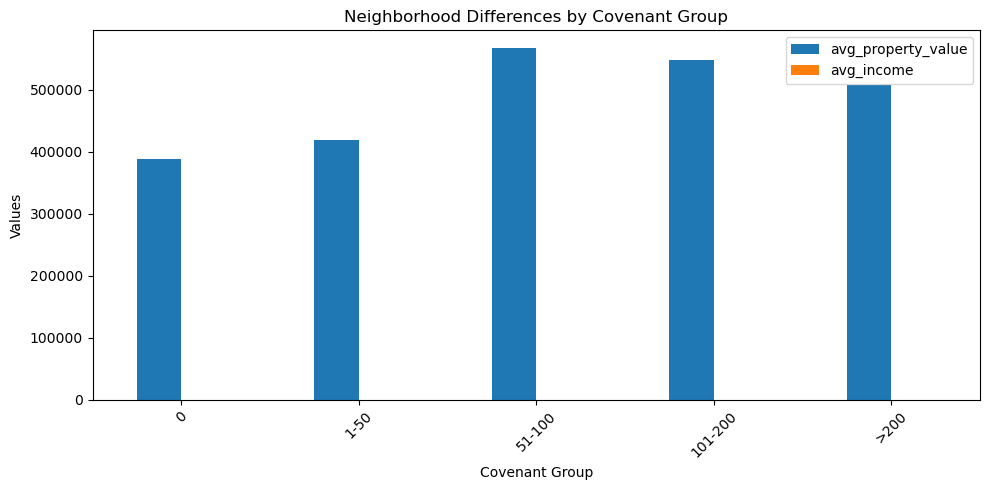

In [40]:
neighborhood_summary[["avg_property_value", "avg_income"]].plot(kind="bar", figsize=(10,5))
plt.title("Neighborhood Differences by Covenant Group")
plt.xlabel("Covenant Group")
plt.ylabel("Values")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()